# StayWise — Revenue Leakage Analysis (pandas walkthrough)

**Business question:** where is the hotel group losing revenue to cancellations, and which segment should the Revenue Manager act on first?

This notebook reproduces the analysis in `scripts/build_staywise.py` using **pandas / NumPy / matplotlib**, so every number in the executive summary, the SQL views and the dashboard can be re-derived and checked here.

Data: the public *Hotel Booking Demand* dataset (119,390 real reservations, two hotels in Portugal, arrivals Jul 2015 – Aug 2017), transformed into a star schema (`data/processed/`). Commission rates, room inventory and deposit-recovery rates are **synthetic, documented assumptions** (see `docs/Data_Dictionary.md`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.width", 160)

bookings = pd.read_csv(ROOT / "data/processed/fact_bookings.csv", parse_dates=["arrival_date"])
inventory = pd.read_csv(ROOT / "data/processed/fact_daily_inventory.csv", parse_dates=["date"])
summary_csv = pd.read_csv(ROOT / "outputs/executive_summary.csv").iloc[0]

print(f"fact_bookings: {bookings.shape[0]:,} rows x {bookings.shape[1]} columns")
print(f"arrival window: {bookings.arrival_date.min().date()} to {bookings.arrival_date.max().date()}")
bookings.head(3)

fact_bookings: 119,390 rows x 43 columns
arrival window: 2015-07-01 to 2017-08-31


,booking_id,arrival_date,date_id,arrival_year_month,property_id,channel_id,market_segment_id,customer_type_id,room_type_id,country_id,...,room_nights_booked,room_nights_realized,previous_cancellations,previous_cancel_band,total_special_requests,special_request_band,booking_changes,days_in_waiting_list,required_car_parking_spaces,room_mismatch_flag
0,SW000001,2015-07-01,20150701,2015-07,P001,CH002,MS004,CT003,RT003,CO137,...,1,1,0,No previous cancellations,0,No requests,3,0,0,0
1,SW000002,2015-07-01,20150701,2015-07,P001,CH002,MS004,CT003,RT003,CO137,...,1,1,0,No previous cancellations,0,No requests,4,0,0,0
2,SW000003,2015-07-01,20150701,2015-07,P001,CH002,MS004,CT003,RT001,CO060,...,1,1,0,No previous cancellations,0,No requests,0,0,0,1


## 1. One booking, one row — the grain of the model

Every revenue KPI is calculated **once per booking** and then summed, so the same definitions give the same answer in Python, SQL, DAX and Excel. The key columns:

| Column | Meaning |
|---|---|
| `potential_revenue` | `adr × stay_nights` — what the booking was worth if honored |
| `cancellation_fee_revenue` | money kept on a cancellation under the deposit policy (85% Non Refund, 20% Refundable, 0% No Deposit) |
| `realized_revenue` | stay revenue + cancellation fee revenue — money actually kept |
| `lost_revenue` | potential − realized (on canceled bookings) — **revenue leakage** |
| `commission_cost` / `net_revenue` | channel cost (2–18% by channel) and revenue after that cost |

In [2]:
bookings[["hotel_source", "distribution_channel", "lead_time_band", "deposit_type", "is_canceled",
          "adr", "stay_nights", "potential_revenue", "cancellation_fee_revenue", "realized_revenue",
          "lost_revenue", "commission_cost", "net_revenue"]].sample(5, random_state=7)

,hotel_source,distribution_channel,lead_time_band,deposit_type,is_canceled,adr,stay_nights,potential_revenue,cancellation_fee_revenue,realized_revenue,lost_revenue,commission_cost,net_revenue
71902,City Hotel,TA/TO,31-90 days,No Deposit,1,135.00,2,270.00,0.00,0.00,270.00,0.00,0.00
51736,City Hotel,TA/TO,91-180 days,Non Refund,1,130.00,2,260.00,221.00,221.00,39.00,39.78,181.22
101138,City Hotel,TA/TO,31-90 days,No Deposit,0,79.20,1,79.20,0.00,79.20,0.00,14.26,64.94
28656,Resort Hotel,TA/TO,181+ days,No Deposit,0,48.00,3,144.00,0.00,144.00,0.00,25.92,118.08
52793,City Hotel,TA/TO,31-90 days,Non Refund,1,120.00,6,720.00,612.00,612.00,108.00,110.16,501.84


## 2. Data-quality gate: the reconciliation identity

Before trusting any aggregate, check the booking-level identity **Potential = Realized + Lost** on all 119,390 rows, plus the sign and cancellation-logic rules that `sql/03_quality_checks.sql` also enforces.

In [3]:
diff = bookings.potential_revenue - (bookings.realized_revenue + bookings.lost_revenue)
checks = {
    "potential = realized + lost (±1 cent)": np.isclose(diff, 0, atol=0.011).all(),
    "no negative revenue fields": (bookings[["potential_revenue", "realized_revenue", "lost_revenue", "cancellation_fee_revenue"]] >= 0).all().all(),
    "non-canceled bookings have zero lost revenue": (bookings.loc[bookings.is_canceled == 0, "lost_revenue"] == 0).all(),
    "canceled bookings keep only the fee": np.isclose(bookings.loc[bookings.is_canceled == 1, "realized_revenue"],
                                                     bookings.loc[bookings.is_canceled == 1, "cancellation_fee_revenue"]).all(),
    "booking_id is unique": bookings.booking_id.is_unique,
    "no nulls in revenue columns": bookings[["potential_revenue", "realized_revenue", "lost_revenue"]].notna().all().all(),
}
pd.Series(checks, name="passed").to_frame()

,passed
potential = realized + lost (±1 cent),True
no negative revenue fields,True
non-canceled bookings have zero lost revenue,True
canceled bookings keep only the fee,True
booking_id is unique,True
no nulls in revenue columns,True


## 3. Executive KPIs — and a cross-check against the pipeline output

`available_room_nights` comes from the synthetic capacity table (280 resort rooms + 450 city rooms per day, ±2% seasonal). Because the public dataset is a sample of bookings rather than the hotels' full ledger, modeled occupancy (~44%) is lower than a real hotel reports — the ratio is still valid for comparing months, properties and scenarios.

In [4]:
available_nights = inventory.available_room_nights.sum()
kpi = pd.Series({
    "bookings": len(bookings),
    "cancellations": bookings.is_canceled.sum(),
    "cancellation_rate": bookings.is_canceled.mean(),
    "potential_revenue": bookings.potential_revenue.sum(),
    "realized_revenue": bookings.realized_revenue.sum(),
    "lost_revenue": bookings.lost_revenue.sum(),
    "cancellation_fee_revenue": bookings.cancellation_fee_revenue.sum(),
    "commission_cost": bookings.commission_cost.sum(),
    "net_revenue": bookings.net_revenue.sum(),
    "room_nights_realized": bookings.room_nights_realized.sum(),
    "available_room_nights": available_nights,
})
kpi["occupancy_rate"] = kpi.room_nights_realized / available_nights
kpi["adr"] = kpi.realized_revenue / kpi.room_nights_realized
kpi["revpar"] = kpi.realized_revenue / available_nights
kpi["net_revpar"] = kpi.net_revenue / available_nights

compare = pd.DataFrame({"notebook": kpi, "pipeline_csv": summary_csv.reindex(kpi.index).astype(float)})
compare["match"] = np.isclose(compare.notebook, compare.pipeline_csv, rtol=1e-4, atol=0.02)
assert compare.match.all(), "notebook KPIs diverge from outputs/executive_summary.csv"
compare

,notebook,pipeline_csv,match
bookings,"119,390.00","119,390.00",True
cancellations,"44,224.00","44,224.00",True
cancellation_rate,0.37,0.37,True
potential_revenue,"42,723,561.33","42,723,561.33",True
realized_revenue,"29,064,010.59","29,064,010.59",True
lost_revenue,"13,659,550.74","13,659,550.74",True
cancellation_fee_revenue,"3,067,686.38","3,067,686.38",True
commission_cost,"4,386,314.88","4,386,314.88",True
net_revenue,"24,677,691.54","24,677,691.54",True
room_nights_realized,"255,720.00","255,720.00",True


**Reading the numbers:** of $42.7M potential revenue, $13.7M (32%) leaked through cancellations after deposit recovery, and a further $4.4M went to channel commissions. RevPAR ($50) = ADR ($114) × occupancy (44%).

## 4. Where do cancellations concentrate? Single-factor driver analysis

For each booking attribute, compare the group's cancellation rate to the portfolio average (37.0%). `lift` is the percentage-point difference.

In [5]:
base_rate = bookings.is_canceled.mean()

def driver_table(col):
    g = (bookings.groupby(col)
         .agg(bookings=("booking_id", "size"), cancellations=("is_canceled", "sum"),
              cancellation_rate=("is_canceled", "mean"), lost_revenue=("lost_revenue", "sum"))
         .assign(lift_vs_avg=lambda d: d.cancellation_rate - base_rate)
         .sort_values("lost_revenue", ascending=False))
    g.index.name = col
    return g

drivers = {col: driver_table(col) for col in
           ["hotel_source", "lead_time_band", "deposit_type", "distribution_channel",
            "market_segment", "special_request_band", "previous_cancel_band", "customer_type"]}

for col in ["hotel_source", "lead_time_band", "deposit_type", "distribution_channel"]:
    print(f"\n=== {col} ===")
    print(drivers[col].to_string(formatters={"cancellation_rate": "{:.1%}".format, "lift_vs_avg": "{:+.1%}".format,
                                             "lost_revenue": "${:,.0f}".format}))


=== hotel_source ===
              bookings  cancellations cancellation_rate lost_revenue lift_vs_avg
hotel_source                                                                    
City Hotel       79330          33102             41.7%   $8,191,604       +4.7%
Resort Hotel     40060          11122             27.8%   $5,467,947       -9.3%

=== lead_time_band ===
                bookings  cancellations cancellation_rate lost_revenue lift_vs_avg
lead_time_band                                                                    
91-180 days        26439          11821             44.7%   $4,094,254       +7.7%
31-90 days         29553          11141             37.7%   $3,802,931       +0.7%
181+ days          24692          14077             57.0%   $3,376,706      +20.0%
8-30 days          18960           5283             27.9%   $1,948,123       -9.2%
0-7 days           19746           1902              9.6%     $437,536      -27.4%

=== deposit_type ===
              bookings  can

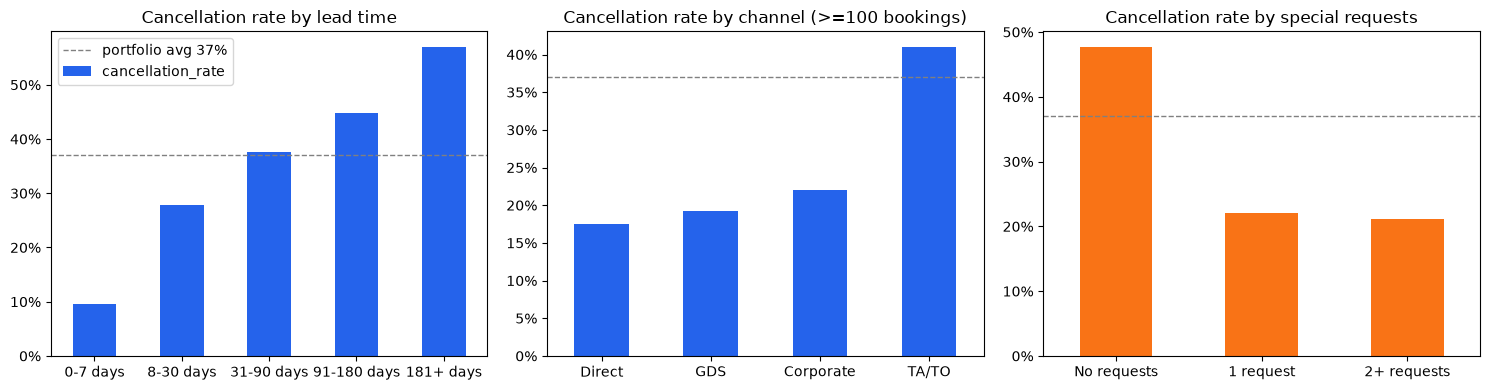

In [6]:
lead_order = ["0-7 days", "8-30 days", "31-90 days", "91-180 days", "181+ days"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

drivers["lead_time_band"].reindex(lead_order).cancellation_rate.plot.bar(ax=axes[0], color="#2563eb")
axes[0].set_title("Cancellation rate by lead time"); axes[0].set_xlabel("")

chan = drivers["distribution_channel"].query("bookings >= 100").sort_values("cancellation_rate")
chan.cancellation_rate.plot.bar(ax=axes[1], color="#2563eb")
axes[1].set_title("Cancellation rate by channel (>=100 bookings)"); axes[1].set_xlabel("")

req = drivers["special_request_band"].reindex(["No requests", "1 request", "2+ requests"])
req.cancellation_rate.plot.bar(ax=axes[2], color="#f97316")
axes[2].set_title("Cancellation rate by special requests"); axes[2].set_xlabel("")

for ax in axes:
    ax.axhline(base_rate, color="grey", linestyle="--", linewidth=1, label=f"portfolio avg {base_rate:.0%}")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.tick_params(axis="x", rotation=0)
axes[0].legend(loc="upper left")
plt.tight_layout()

**What the drivers say**

1. **Lead time is the strongest behavioral signal**: bookings made 0–7 days out cancel ~10% of the time; 181+ days out, ~57%. Long-lead bookings are cheap options for the guest.
2. **City Hotel (42%) cancels far more than Resort Hotel (28%)**, and carries 60% of lost revenue.
3. **Non-Refund deposits cancel ~99%** — counter-intuitive until you see that these are dominated by group / offline tour-operator blocks that are pre-booked and released. The hotel keeps 85% via the fee, so their *lost* revenue is small; the issue there is capacity, not cash.
4. **TA/TO (online + offline travel agents) is 82% of bookings, cancels 41%, and pays 18% commission** — the highest-leakage, highest-cost channel. Direct bookings cancel only 17%.
5. **Zero special requests → 48% cancellation vs 21–22% with one or more.** A request is a commitment signal — useful for a pre-arrival confirmation workflow.

## 5. Channel economics — gross vs net

A channel can look great on realized revenue and poor on net revenue once commission is deducted.

In [7]:
channel = (bookings.pivot_table(index="distribution_channel", columns="hotel_source",
                                values=["realized_revenue", "commission_cost", "net_revenue"], aggfunc="sum")
           .round(0))
channel_total = (bookings.groupby("distribution_channel")
                 .agg(bookings=("booking_id", "size"), cancellation_rate=("is_canceled", "mean"),
                      realized_revenue=("realized_revenue", "sum"), commission_cost=("commission_cost", "sum"),
                      net_revenue=("net_revenue", "sum"))
                 .assign(commission_share=lambda d: d.commission_cost / d.realized_revenue,
                         net_revenue_per_booking=lambda d: d.net_revenue / d.bookings)
                 .sort_values("net_revenue", ascending=False))
channel_total.style.format({"cancellation_rate": "{:.1%}", "commission_share": "{:.1%}",
                            "realized_revenue": "${:,.0f}", "commission_cost": "${:,.0f}",
                            "net_revenue": "${:,.0f}", "net_revenue_per_booking": "${:,.0f}"})

,bookings,cancellation_rate,realized_revenue,commission_cost,net_revenue,commission_share,net_revenue_per_booking
distribution_channel,,,,,,,
TA/TO,97870,41.0%,"$23,708,120","$4,267,452","$19,440,664",18.0%,$199
Direct,14645,17.5%,"$4,417,321","$88,346","$4,328,975",2.0%,$296
Corporate,6677,22.1%,"$904,998","$27,148","$877,849",3.0%,$131
GDS,193,19.2%,"$33,008","$3,301","$29,707",10.0%,$154
Undefined,5,80.0%,$564,$68,$496,12.0%,$99


## 6. Sizing the opportunities — segment ranking rebuilt in pandas

Group by **property × market segment × channel × lead-time band × deposit type**, keep segments with ≥120 bookings (noise floor), then estimate what a targeted intervention could recover:

- `excess_rate = max(segment_rate − portfolio_rate, 0)`
- `achievable_reduction = clip(0.65 × excess_rate, 6%, 35%)` — an *assumption*: a targeted fix recovers about two-thirds of a segment's excess cancellations, with a floor and a ceiling
- `recoverable_revenue = lost_revenue × achievable_reduction`
- `priority_score = recoverable/1000 + cancellation_rate × 25 + bookings/1000` — balances money, risk and reach

This must reproduce `outputs/segment_opportunity_rankings.csv` exactly.

In [8]:
keys = ["property_id", "hotel_source", "market_segment", "distribution_channel", "lead_time_band", "deposit_type"]
opp = (bookings.groupby(keys)
       .agg(bookings=("booking_id", "size"), cancellations=("is_canceled", "sum"),
            lost_revenue=("lost_revenue", "sum"), realized_revenue=("realized_revenue", "sum"))
       .query("bookings >= 120")
       .reset_index())
opp["cancellation_rate"] = opp.cancellations / opp.bookings
opp["excess_rate"] = (opp.cancellation_rate - base_rate).clip(lower=0)
opp["achievable_reduction"] = (opp.excess_rate * 0.65).clip(0.06, 0.35)
opp["recoverable_revenue"] = opp.lost_revenue * opp.achievable_reduction
opp["priority_score"] = opp.recoverable_revenue / 1000 + opp.cancellation_rate * 25 + opp.bookings / 1000
opp = opp.sort_values("priority_score", ascending=False).reset_index(drop=True)
opp.index = opp.index + 1

pipeline = pd.read_csv(ROOT / "outputs/segment_opportunity_rankings.csv").head(10).rename(columns={"property_source": "hotel_source"})
top10 = opp.head(10)
assert (top10[keys].values == pipeline[keys].values).all(), "ranking order differs from pipeline"
assert np.allclose(top10.recoverable_revenue, pipeline.estimated_recoverable_revenue, atol=1), "recoverable revenue differs"
print("Top-10 ranking matches outputs/segment_opportunity_rankings.csv")

top10[["hotel_source", "market_segment", "distribution_channel", "lead_time_band", "deposit_type",
       "bookings", "cancellation_rate", "lost_revenue", "achievable_reduction", "recoverable_revenue", "priority_score"]] \
    .style.format({"cancellation_rate": "{:.1%}", "achievable_reduction": "{:.1%}",
                   "lost_revenue": "${:,.0f}", "recoverable_revenue": "${:,.0f}", "priority_score": "{:.1f}"})

Top-10 ranking matches outputs/segment_opportunity_rankings.csv


,hotel_source,market_segment,distribution_channel,lead_time_band,deposit_type,bookings,cancellation_rate,lost_revenue,achievable_reduction,recoverable_revenue,priority_score
1,Resort Hotel,Online TA,TA/TO,181+ days,No Deposit,2593,56.8%,"$1,195,974",12.8%,"$153,351",170.1
2,City Hotel,Online TA,TA/TO,31-90 days,No Deposit,11728,39.7%,"$1,922,647",6.0%,"$115,359",137.0
3,City Hotel,Online TA,TA/TO,91-180 days,No Deposit,9414,43.0%,"$1,845,763",6.0%,"$110,746",130.9
4,City Hotel,Online TA,TA/TO,181+ days,No Deposit,4874,51.8%,"$1,120,106",9.6%,"$107,342",125.2
5,Resort Hotel,Online TA,TA/TO,91-180 days,No Deposit,3801,48.3%,"$1,326,099",7.3%,"$96,843",112.7
6,City Hotel,Online TA,TA/TO,8-30 days,No Deposit,7620,34.5%,"$1,098,831",6.0%,"$65,930",82.2
7,Resort Hotel,Online TA,TA/TO,31-90 days,No Deposit,4675,39.6%,"$1,038,896",6.0%,"$62,334",76.9
8,City Hotel,Groups,TA/TO,181+ days,Non Refund,4377,100.0%,"$124,454",35.0%,"$43,559",72.9
9,City Hotel,Offline TA/TO,TA/TO,181+ days,Non Refund,2249,100.0%,"$87,111",35.0%,"$30,489",57.7
10,City Hotel,Groups,TA/TO,91-180 days,Non Refund,1699,100.0%,"$79,151",35.0%,"$27,703",54.4


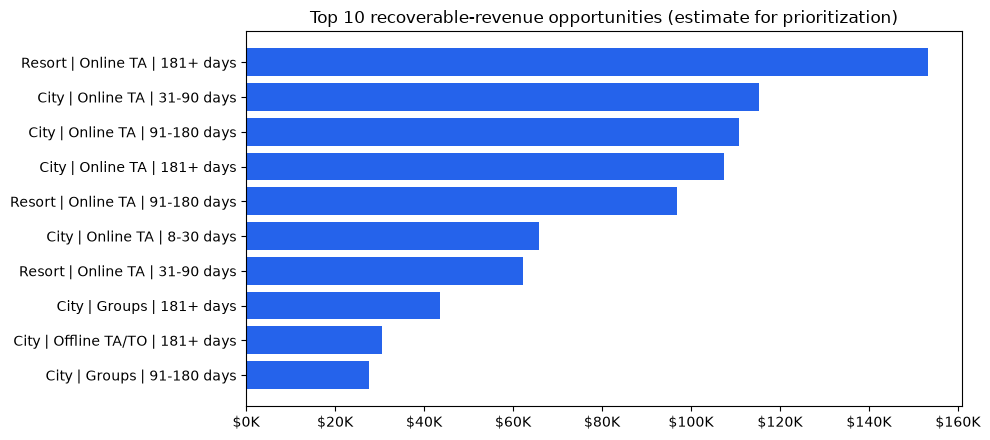

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
labels = top10.apply(lambda r: f"{r.hotel_source.split()[0]} | {r.market_segment} | {r.lead_time_band}", axis=1)
ax.barh(labels[::-1], top10.recoverable_revenue[::-1], color="#2563eb")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
ax.set_title("Top 10 recoverable-revenue opportunities (estimate for prioritization)")
plt.tight_layout()

**Why #1 is Resort Hotel · Online TA · 181+ days:** 2,593 bookings, a 56.8% cancellation rate (20 points above average), $1.2M lost. A 12.8% achievable reduction gives ~$153K recoverable. City Hotel OTA segments have more *lost* revenue but cancel closer to the average, so the assumed recovery is smaller. The Non-Refund group blocks cancel ~100% but the hotel already keeps 85% via fees, so their recoverable cash is limited — those are a capacity-resale problem, not a deposit-policy problem.

## 7. Monthly trend — realized vs lost

,realized_revenue,lost_revenue,leakage_share
month,,,
2017-03,"977,645.77","434,711.47",0.31
2017-04,"1,406,265.00","781,217.01",0.36
2017-05,"1,603,271.07","849,115.17",0.35
2017-06,"1,708,364.88","892,537.61",0.34
2017-07,"1,861,612.68","1,271,346.39",0.41
2017-08,"1,983,412.46","1,365,214.07",0.41


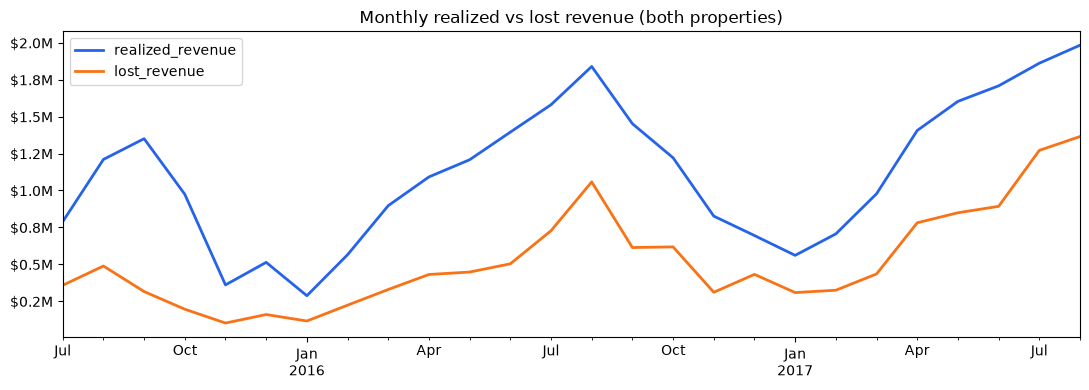

In [10]:
monthly = (bookings.assign(month=bookings.arrival_date.dt.to_period("M"))
           .groupby("month")[["realized_revenue", "lost_revenue"]].sum())
ax = monthly.plot(figsize=(11, 4), color=["#2563eb", "#f97316"], linewidth=2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
ax.set_title("Monthly realized vs lost revenue (both properties)"); ax.set_xlabel("")
plt.tight_layout()
monthly.assign(leakage_share=monthly.lost_revenue / (monthly.realized_revenue + monthly.lost_revenue)).tail(6)

## 8. How the cancellation risk score works (interpretable, not ML)

The pipeline gives each booking a **rule-based risk score** so operations can triage. It is *not* a trained machine-learning model — it is a transparent additive scorer:

1. For each of 7 features (lead-time band, channel, market segment, customer type, deposit type, special requests, previous cancellations), compute the cancellation rate of each value, smoothed toward the portfolio average so tiny groups don't get extreme rates.
2. Convert rates to log-odds (`logit`). A booking's score starts at the portfolio log-odds and adds 0.42 × (feature log-odds − base log-odds) for each of its 7 feature values. The 0.42 damping keeps overlapping signals (e.g. *Groups* segment and *Non Refund* deposit) from double counting.
3. Convert back with a sigmoid to a 0–1 risk, and band it: Low < 25%, Medium 25–45%, High ≥ 45%.
4. **Feature importance** = booking-weighted average gap between a feature's group rates and the base rate — i.e. how much a feature moves cancellations.

The check below shows the bands are well calibrated: actual cancellation rates rise from ~14% (Low) to ~84% (High), close to the average predicted risk in each band.

In [11]:
risk = pd.read_csv(ROOT / "outputs/cancellation_risk_segments.csv").set_index("risk_band")
importance = pd.read_csv(ROOT / "outputs/model_feature_importance.csv").set_index("feature")
display(risk.style.format({"actual_cancellation_rate": "{:.1%}", "average_predicted_risk": "{:.1%}", "lost_revenue": "${:,.0f}"}))
importance[["importance_score", "importance_share", "business_interpretation"]].style.format({"importance_score": "{:.3f}", "importance_share": "{:.1%}"})

,bookings,actual_cancellations,actual_cancellation_rate,average_predicted_risk,lost_revenue
risk_band,,,,,
Low risk,38130,5242,13.8%,17.6%,"$2,039,110"
Medium risk,58089,19559,33.7%,34.4%,"$9,195,265"
High risk,23171,19423,83.8%,78.3%,"$2,425,175"


,importance_score,importance_share,business_interpretation
feature,,,
Deposit type,0.152,23.2%,Deposit rules materially change cancellation incentives.
Special requests,0.126,19.1%,Special requests proxy customer commitment and trip intent.
Lead time,0.120,18.2%,Longer booking windows create more exposure to cancellation behavior.
Market segment,0.080,12.1%,Customer purpose and acquisition source change booking certainty.
Channel,0.065,9.9%,Channel behavior affects cancellation rate and net revenue after commission.
Previous cancellations,0.059,9.0%,Prior cancellation history indicates repeat risk behavior.
Customer type,0.056,8.5%,"Contract, group, transient, and party bookings behave differently."


## 9. Findings and recommendation

| # | Finding | Number |
|---|---|---|
| 1 | Cancellations are the dominant leak | 37.0% of bookings; $13.7M lost after deposit recovery (32% of potential revenue) |
| 2 | Lead time is the strongest behavioral driver | 9.6% (0–7 days) → 57.0% (181+ days) |
| 3 | City Hotel is the bigger problem | 41.7% vs 27.8%; 60% of lost revenue |
| 4 | Travel-agent channel is high leakage *and* high cost | 82% of bookings, 41% cancel rate, 18% commission = $4.3M |
| 5 | Direct bookings are the healthiest | 17.5% cancel, 2% commission |
| 6 | Commitment signals matter | 0 special requests → 48% cancel vs 21% with 2+ |

**Recommendation:** pilot a *staged deposit or reconfirmation workflow* for high-lead (181+ day) online-travel-agent bookings at the Resort Hotel — the #1 ranked segment (~$153K estimated recoverable). Owner: Revenue Manager.

**How to measure it:** treatment vs. a matched control group over the same arrival window. Primary metric: cancellation rate. Guardrails: booking conversion, ADR, realized revenue, Net RevPAR. The recoverable figure is a prioritization hypothesis, not a causal claim, until the pilot reads out.

**Limitations:** historical public data; commission, inventory and deposit-recovery rates are documented assumptions; the risk score is descriptive, not predictive of future policy changes.